<a href="https://colab.research.google.com/github/bpucalderon001/SpringBreak/blob/main/Springbreak_ipybn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Prep
!pip install keras_unet_collection

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from keras_unet_collection import losses
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow import keras
from tensorflow.keras import layers

!curl -L -o images.npz https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/images.npz
!curl -L -o masks.npz https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/masks.npz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.0 MB/s eta 0:00:00
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 9601k  100 9601k    0     0  7464k      0  0:00:01  0:00:01 --:--:-- 18.4M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 92714  100 92714    0     0   336k      0 --:--:-- --:--:-- --:--:--  336k


In [ ]:
images = np.load("images.npz")["images"]
masks = np.load("masks.npz")["masks"]

images = images[:, 24:]
masks = masks[:, 24:]
images = images[:,:,:,0]

images = images / 255.0
masks = (masks > 0).astype("float32")

def pad(x):
    return np.pad(x[..., None], ((0, 0), (22, 22), (10, 10), (0, 0)))

print(images.shape)
print(masks.shape)

(208, 276, 300)
(208, 276, 300)


In [ ]:
images = pad(images)
masks = pad(masks)

idx = np.random.permutation(len(images))
images = images[idx]
masks = masks[idx]

In [ ]:
X_train = images[:180]
y_train = masks[:180]

X_test = images[180:]
y_test = masks[180:]

In [ ]:
# Callbacks
checkpoint = ModelCheckpoint(
    'best_unet_plus.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# model = models.unet_plus_2d(
#     input_size=(320, 320, 1),
#     filter_num=[64, 128, 256, 512],
#     n_labels=1,
#     output_activation="Sigmoid",
# )

# Keras does not have a build-in dropout function for its high level functions, so I have to build a UNet from zero
def conv_block(x, filters, dropout_rate=0.0):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if dropout_rate > 0:
        x = layers.SpatialDropout2D(dropout_rate)(x)

    return x

def build_unet_dropout(input_shape=(320, 320, 1), dropout_rates=(0.0, 0.1, 0.2, 0.3)):
    inputs = keras.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, 64, dropout_rates[0])
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 128, dropout_rates[1])
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 256, dropout_rates[2])
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 512, dropout_rates[3])

    # Decoder
    u3 = layers.UpSampling2D((2, 2))(c4)
    u3 = layers.Concatenate()([u3, c3])
    c5 = conv_block(u3, 256, 0.2)

    u2 = layers.UpSampling2D((2, 2))(c5)
    u2 = layers.Concatenate()([u2, c2])
    c6 = conv_block(u2, 128, 0.1)

    u1 = layers.UpSampling2D((2, 2))(c6)
    u1 = layers.Concatenate()([u1, c1])
    c7 = conv_block(u1, 64, 0.0)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c7)

    return keras.Model(inputs, outputs, name="unet_dropout")

model = build_unet_dropout(input_shape=(320, 320, 1))


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.Dice(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="bin_acc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

In [ ]:
model.summary()

Model: "unet_dropout"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 320, 320,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 320, 320,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 320, 320,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 160, 160,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 160, 160,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 160, 160,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 160, 160,  │          0 │ activation_3[0][… │
│ (SpatialDropout2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 80, 80,    │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 80, 80,    │    295,168 │ max_pooling2d_1[

 Total params: 7,793,025 (29.73 MB)

 Trainable params: 7,787,393 (29.71 MB)

 Non-trainable params: 5,632 (22.00 KB)

In [ ]:
history = model.fit(X_train, y_train, batch_size=16, epochs=50, validation_split=0.1, callbacks=[checkpoint, early_stopping])

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26s/step - bin_acc: 0.6412 - loss: 0.7836 - precision: 0.1610 - recall: 0.8947 
Epoch 1: val_loss improved from None to 0.87814, saving model to best_unet_plus.keras

Epoch 1: finished saving model to best_unet_plus.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 307s 27s/step - bin_acc: 0.7208 - loss: 0.7422 - precision: 0.1970 - recall: 0.9508 - val_bin_acc: 0.9281 - val_loss: 0.8781 - val_precision: 0.0266 - val_recall: 0.0013
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - bin_acc: 0.8281 - loss: 0.6524 - precision: 0.2890 - recall: 0.9819 
Epoch 2: val_loss did not improve from 0.87814
11/11 ━━━━━━━━━━━━━━━━━━━━ 288s 26s/step - bin_acc: 0.8365 - loss: 0.6396 - precision: 0.3010 - recall: 0.9814 - val_bin_acc: 0.9314 - val_loss: 0.8786 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - bin_acc: 0.8723 - loss: 0.6039 - precision: 0.3549 - recall: 0.9728 
Epoch 3: val_loss did not improve from 0.87814

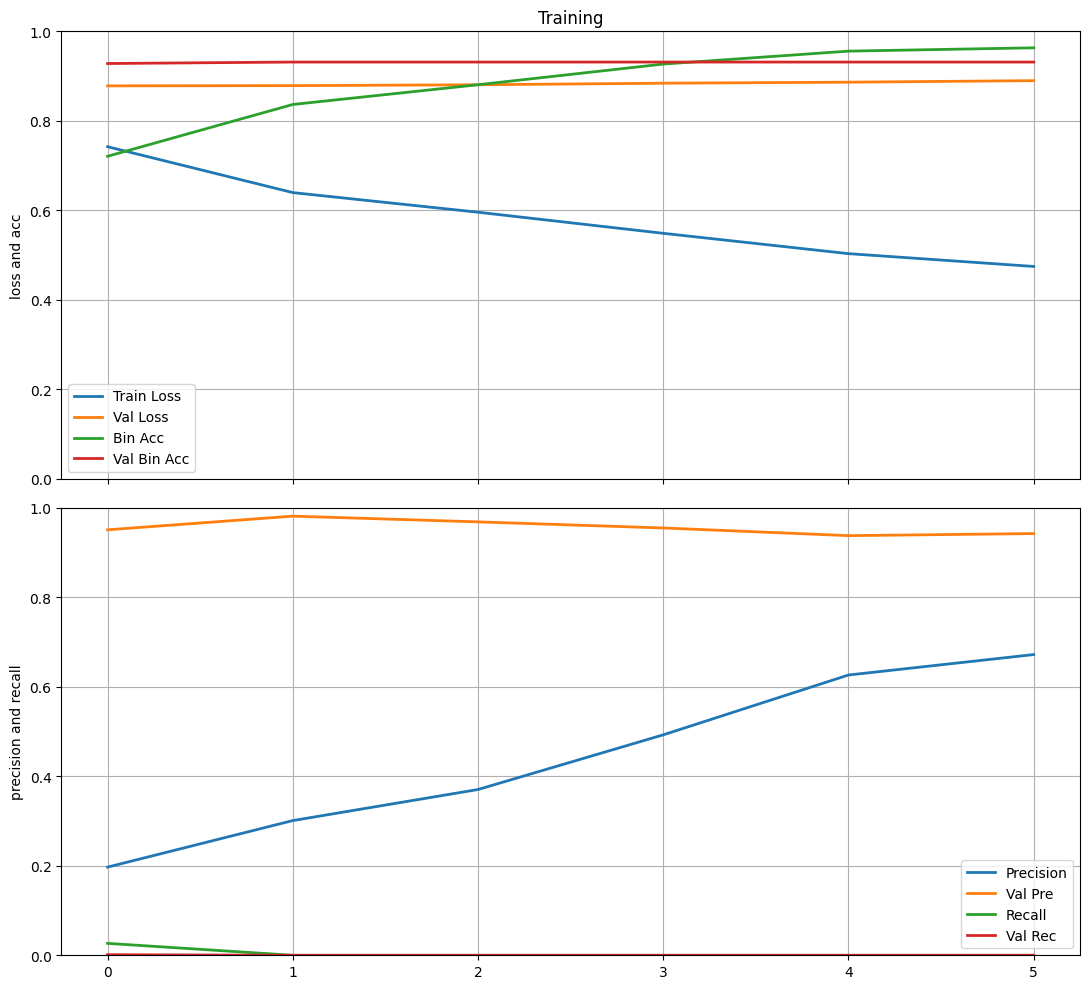

In [ ]:
hist_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

# Training
loss_cols = ['loss', 'val_loss', 'bin_acc', 'val_bin_acc']
hist_df[loss_cols].plot(ax=axes[0], linewidth=2)

axes[0].set_title("Training")
axes[0].set_ylabel("loss and acc")
axes[0].set_ylim(0, 1.0)
axes[0].set_xlabel("epochs")
axes[0].grid(True)
axes[0].legend(['Train Loss', 'Val Loss', 'Bin Acc', 'Val Bin Acc'])


# precision recall
pre_call = ['precision', 'recall', 'val_precision', 'val_recall']
hist_df[pre_call].plot(ax=axes[1], linewidth=2)

axes[1].set_ylabel("precision and recall")
axes[1].set_ylim(0, 1.0)
axes[1].grid(True)
axes[1].legend([
    'Precision', 'Val Pre',
    'Recall', 'Val Rec'
])


plt.tight_layout()
plt.show()

In [ ]:
evaluation_result = model.evaluate(X_test, y_test)
print("Loss:", evaluation_result[0])
print("Accuracy:", evaluation_result[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - bin_acc: 0.9222 - loss: 0.8689 - precision: 0.0766 - recall: 0.0038
Loss: 0.868890106678009
Accuracy: 0.9222244620323181


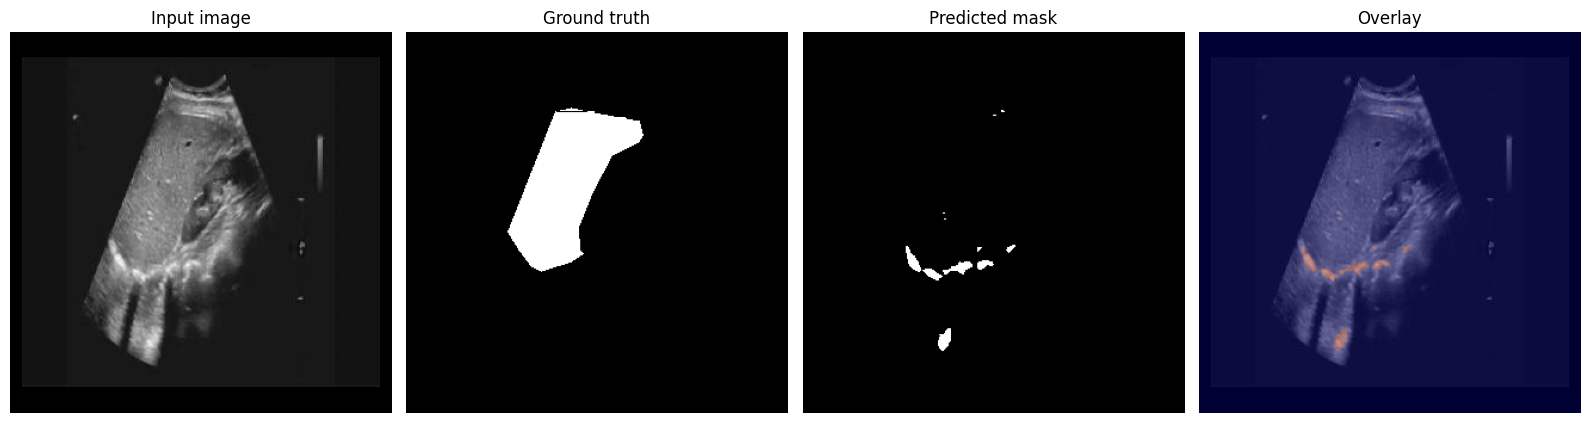

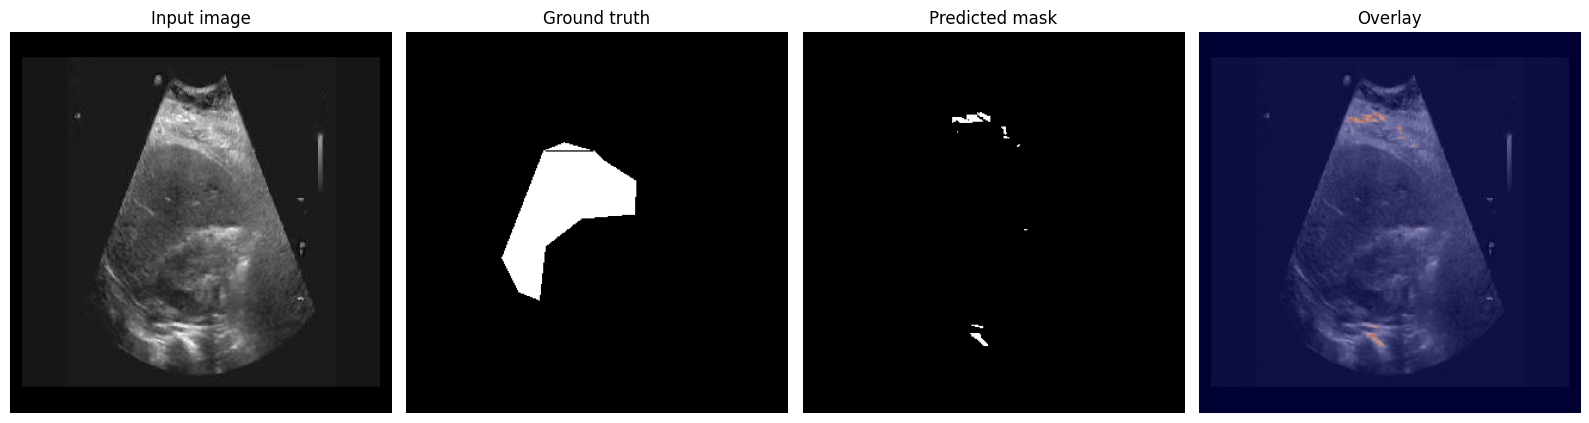

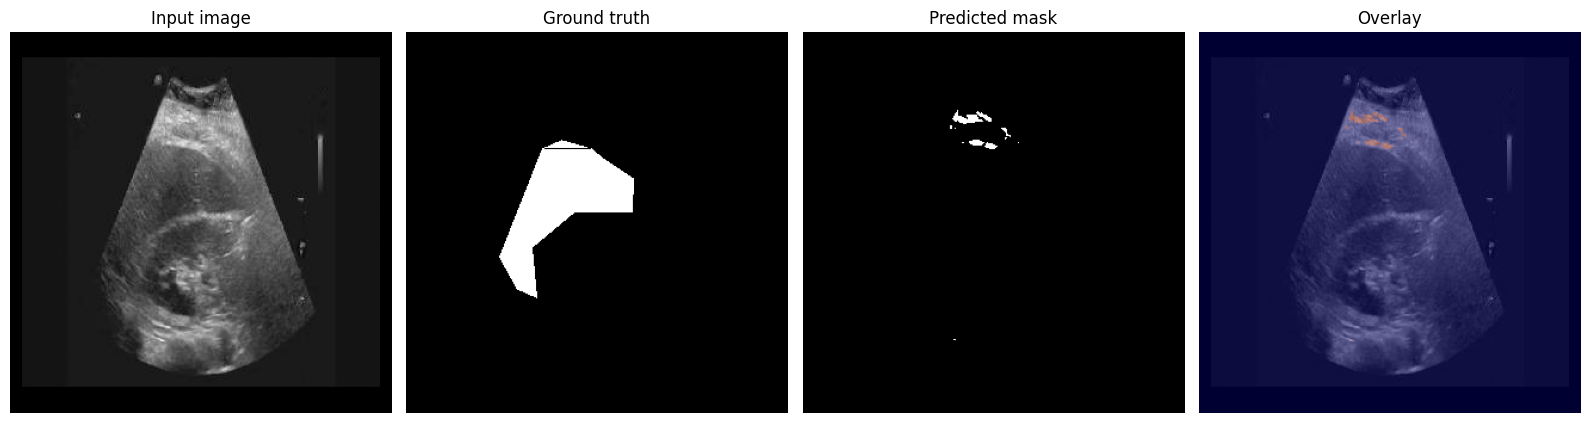

In [ ]:
for i in range(3):
    idx = np.random.randint(0, len(X_test))
    image = X_test[idx]
    mask = y_test[idx]

    pred = model.predict(np.expand_dims(image, axis=0), verbose=0)
    prediction = pred[0]
    prediction_bin = (prediction > 0.5).astype(np.uint8)

    fig, axs = plt.subplots(1, 4, figsize=(16, 6))

    axs[0].imshow(image.squeeze(), cmap="gray")
    axs[0].set_title("Input image")
    axs[0].axis("off")

    axs[1].imshow(mask.squeeze(), cmap="gray")
    axs[1].set_title("Ground truth")
    axs[1].axis("off")

    axs[2].imshow(prediction_bin.squeeze(), cmap="gray")
    axs[2].set_title("Predicted mask")
    axs[2].axis("off")

    axs[3].imshow(image.squeeze(), cmap="gray")
    axs[3].imshow(prediction_bin.squeeze(), cmap="jet", alpha=0.4)
    axs[3].set_title("Overlay")
    axs[3].axis("off")

    plt.tight_layout()
    plt.show()
